# Anomalias: transformar scores em uma fila de revisão

> **Dados integralmente sintéticos.** Execute `python -m src.pipeline` antes deste notebook.

Fraudes são raras (~0,3%). Precisão, recall e área média de precisão são mais informativos que acurácia. O orçamento de alertas é definido pelo percentil 99,7 da validação, sem ajustar limiares no teste.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image
from src.config import DATA, REPORTS, FIGURES


## Treino 2024, validação jan–set/2025, teste out–dez/2025

,model,precision,recall,average_precision,threshold,alerts
0,Isolation Forest,0.501193,0.506024,0.540479,0.703982,838
1,Z-score robusto,0.420989,0.420482,0.408012,3.054577,829
2,STL diário (choques separados),0.076923,1.000000,0.854167,4.000000,52


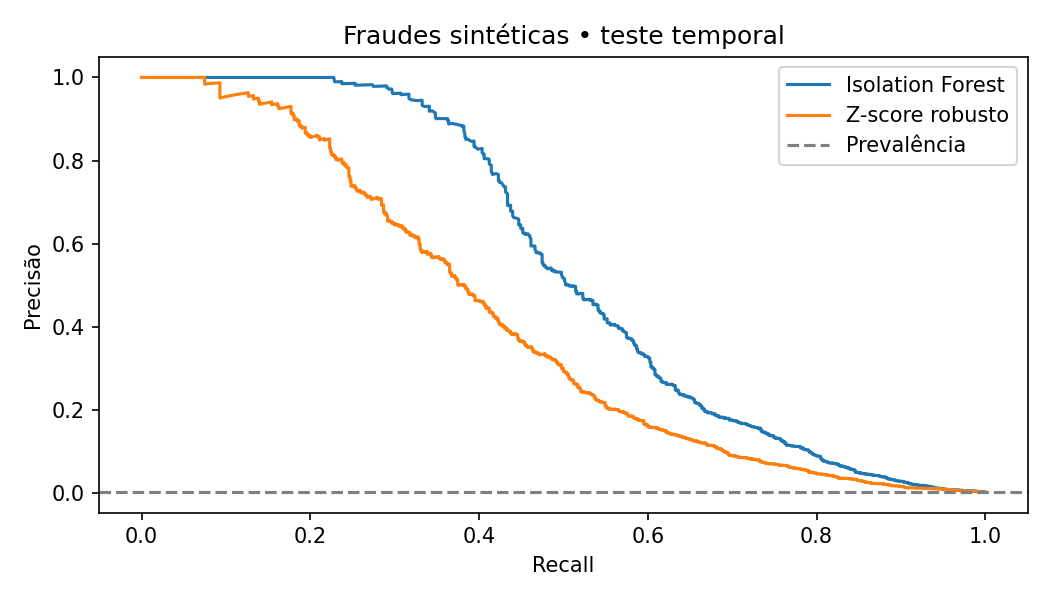

In [2]:
from src.anomalies import run
transactions = pd.read_parquet(DATA / 'transactions.parquet')
display(pd.DataFrame(run(transactions)))
display(Image(filename=str(FIGURES / 'anomaly_pr.png')))

## Casos para investigação

In [3]:
cases = pd.read_csv(REPORTS / 'anomaly_cases.csv')
display(cases.head(10))
print('Falsos positivos entre os 100 maiores scores:')
display(cases.loc[~cases.is_fraud].head(5))

,transaction_id,account_id,date,amount,category,hour,is_fraud,is_holiday,anomaly_score,alert
0,2102689,448,2025-12-28,4656.20,boleto,6,True,False,0.845397,True
1,1912991,26,2025-10-26,2165.50,cartao,1,True,False,0.842959,True
2,2008779,3232,2025-11-26,2943.91,PIX,0,True,False,0.841338,True
3,2007447,1097,2025-11-26,3817.32,PIX,3,True,False,0.841338,True
4,2007621,1380,2025-11-26,3426.03,cartao,3,True,False,0.841338,True
5,2114639,3906,2025-12-31,5028.55,PIX,3,True,False,0.841338,True
6,1950138,542,2025-11-06,3282.73,boleto,6,True,False,0.840529,True
7,1948770,3869,2025-11-05,2456.93,cartao,2,True,False,0.840125,True
8,1878173,2012,2025-10-13,3781.04,PIX,6,True,False,0.839720,True
9,2087234,101,2025-12-22,2994.91,PIX,4,True,False,0.839720,True


Falsos positivos entre os 100 maiores scores:


,transaction_id,account_id,date,amount,category,hour,is_fraud,is_holiday,anomaly_score,alert


## Choques diários: avaliação separada

In [4]:
display(pd.read_csv(REPORTS / 'stl_anomaly_metrics.csv'))
events = pd.read_csv(REPORTS / 'stl_events.csv')
display(events.loc[events.is_injected_event | events.alert])

,model,precision,recall,average_precision,threshold,alerts
0,STL diário (choques separados),0.076923,1.0,0.854167,4,52


,date,amount,score,is_injected_event,alert
1,2025-10-02,365023.780,4.259156,False,True
2,2025-10-03,376210.620,5.161776,False,True
3,2025-10-04,244044.440,4.512788,False,True
4,2025-10-05,250192.620,5.567810,False,True
5,2025-10-06,376376.000,5.312975,False,True
6,2025-10-07,365531.680,4.204123,False,True
7,2025-10-08,374884.200,4.438616,False,True
10,2025-10-11,540538.400,28.413250,True,True
11,2025-10-12,116861.140,17.311580,False,True
14,2025-10-15,281804.250,4.139309,False,True


## Leitura crítica

Isolation Forest usa log do valor, horário noturno e dia da semana; z-score usa log do valor. Valores e horários foram alterados na injeção: a tarefa é mais fácil que fraude real, e o desempenho não deve ser extrapolado. A lista contém só os 100 maiores scores; métricas usam todo o teste. STL estima padrão apenas no passado e avalia quatro choques monetários de 2,5× injetados em uma cópia da série de teste. Esses eventos não são as fraudes individuais e não devem ser comparados diretamente aos outros detectores.